In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA0'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
# Exemple : un groupe de 10 clients
# 8 bons payeurs (classe 0), 2 mauvais (classe 1)

def gini(p1):
    """Gini pour une proba binaire p1."""
    p0 = 1 - p1
    return 1 - (p0**2 + p1**2)

# Scénarios
print(f"Gini 100%/0%  : {gini(0):.3f}  (pur)")
print(f"Gini 80%/20%  : {gini(0.2):.3f}")
print(f"Gini 50%/50%  : {gini(0.5):.3f}  (maximum d'impureté)")
print(f"Gini 10%/90%  : {gini(0.9):.3f}")

Gini 100%/0%  : 0.000  (pur)
Gini 80%/20%  : 0.320
Gini 50%/50%  : 0.500  (maximum d'impureté)
Gini 10%/90%  : 0.180


In [4]:
# Dataset simple : prédire si un étudiant réussit (classification binaire)
np.random.seed(42)
n = 200
df = pd.DataFrame({
    "heures_etude": np.random.uniform(0, 20, n),
    "note_continu": np.random.uniform(0, 20, n),
})
# Règle non-linéaire (intentionnelle : un modèle linéaire ratera)
score = 0.3 * df["heures_etude"] * df["note_continu"] + np.random.normal(0, 3, n)
df["reussit"] = (score > score.median()).astype(int)

# Train/test
X = df[["heures_etude", "note_continu"]]
y = df["reussit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Arbre simple
arbre = DecisionTreeClassifier(max_depth=3, random_state=42)
arbre.fit(X_train, y_train)

print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")

Accuracy train : 0.969
Accuracy test  : 0.900


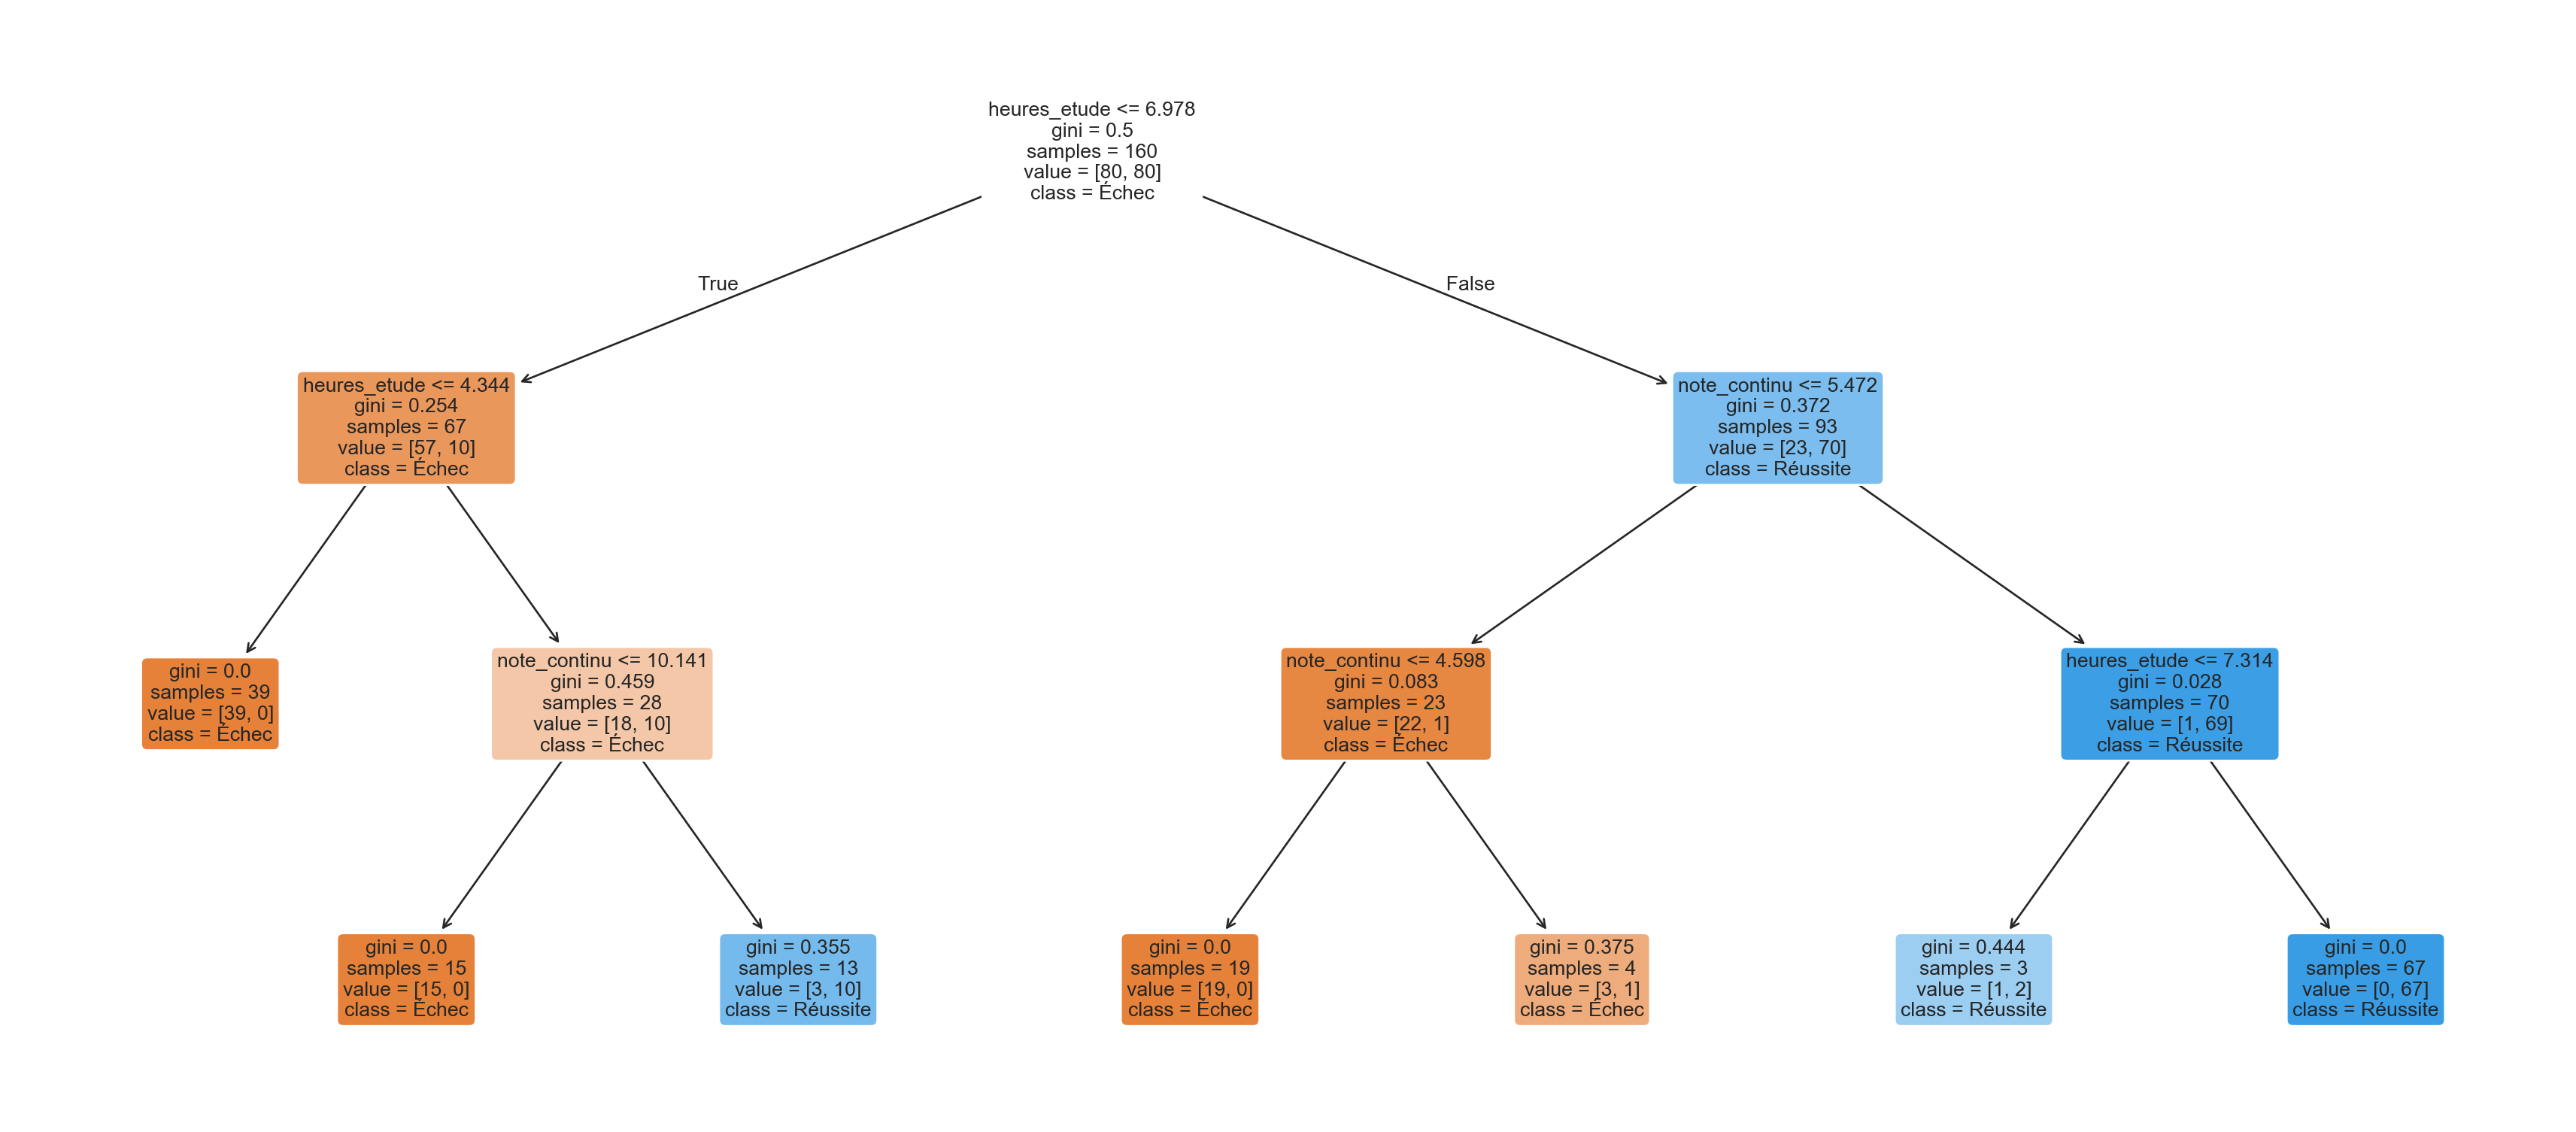

In [5]:
#| label: fig-tree-viz
#| fig-cap: Un arbre de décision de profondeur 3

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(arbre, 
          feature_names=X.columns,
          class_names=["Échec", "Réussite"],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
plt.tight_layout()
plt.show()

C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\loich\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


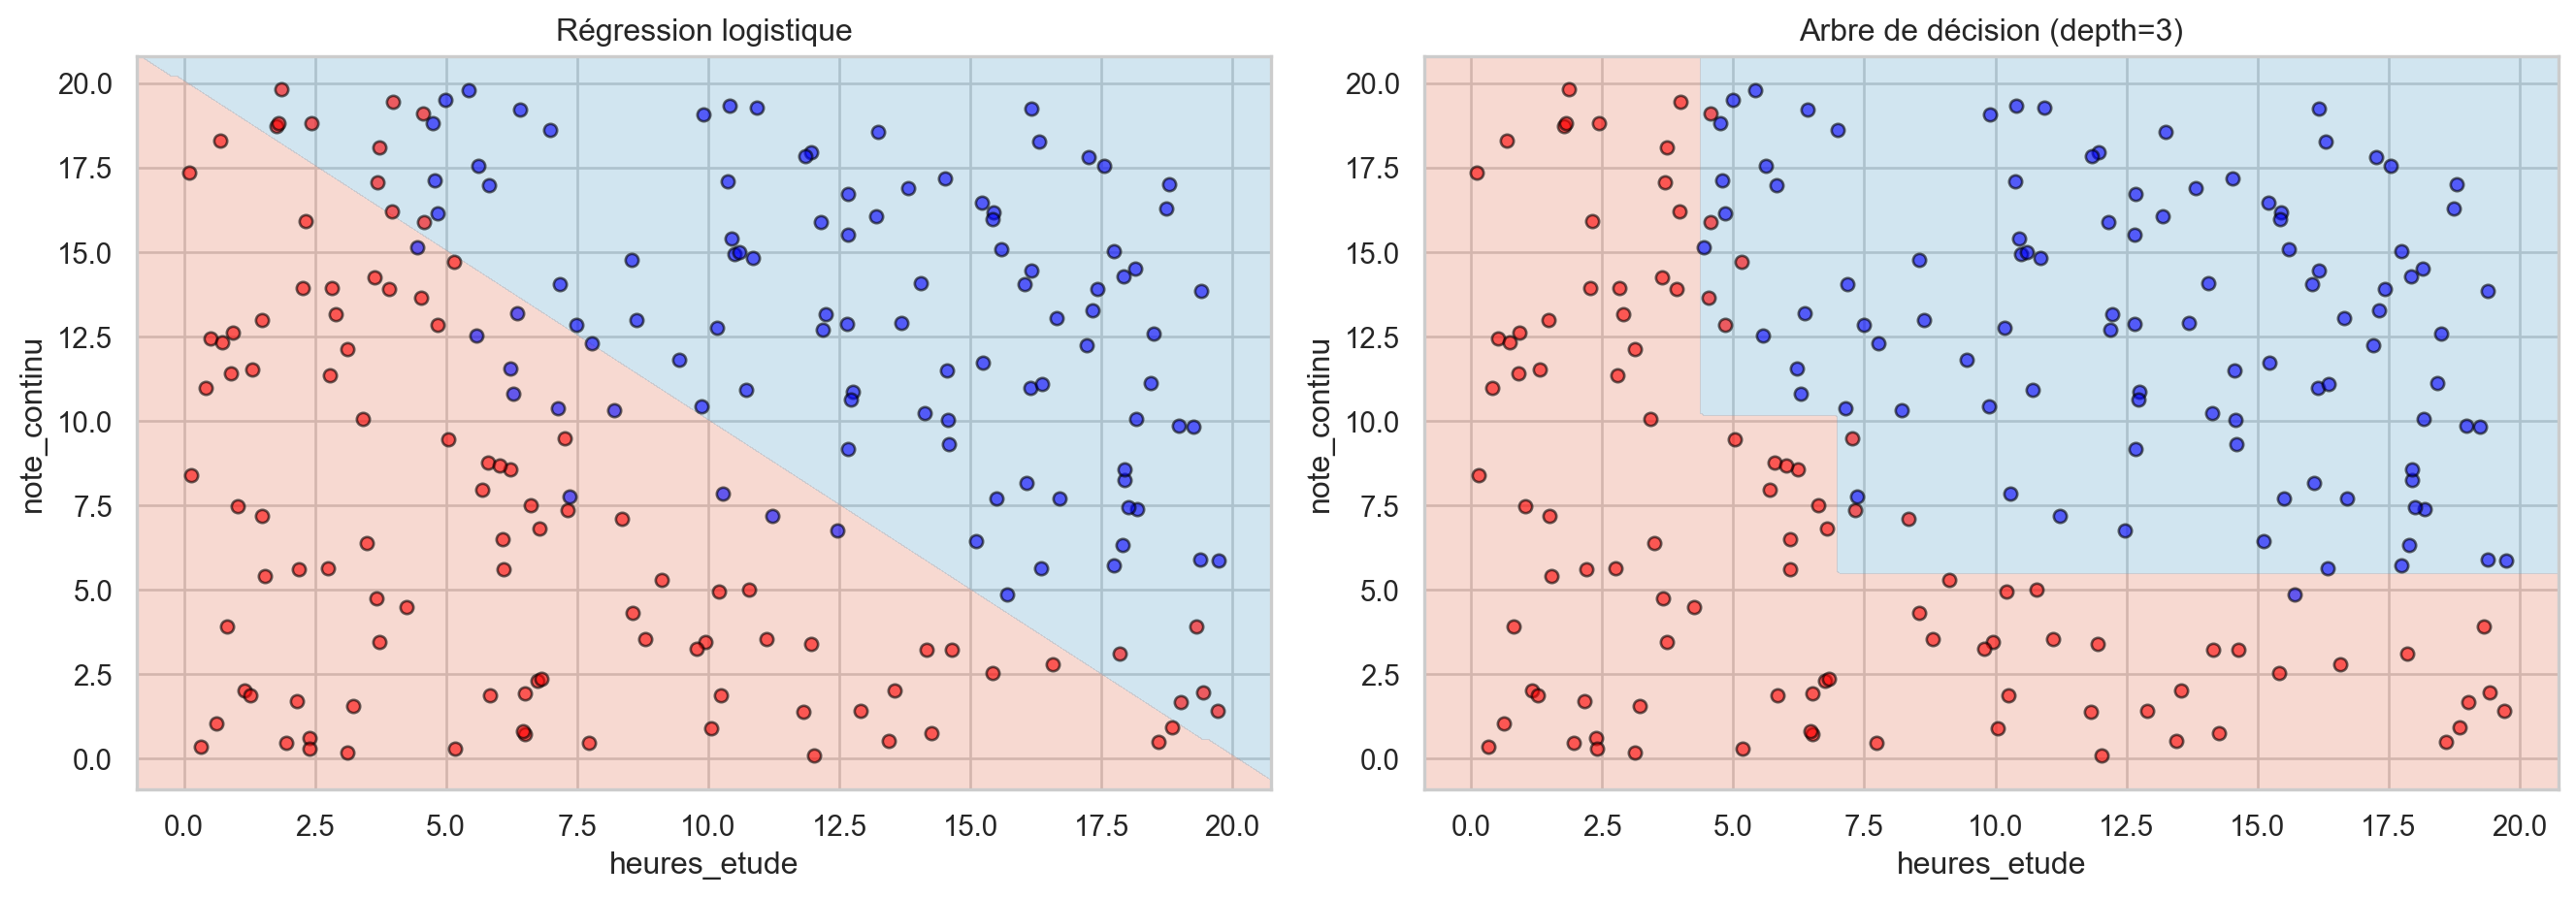

In [6]:
#| label: fig-boundary-tree-vs-logreg
#| fig-cap: 'Arbre vs Régression logistique : frontières très différentes'

# Comparaison visuelle
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train, y_train)

# Grille
x_min, x_max = df["heures_etude"].min() - 1, df["heures_etude"].max() + 1
y_min, y_max = df["note_continu"].min() - 1, df["note_continu"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grille = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nom, mod in zip(axes, 
                         ["Régression logistique", "Arbre de décision (depth=3)"],
                         [logreg, arbre]):
    Z = mod.predict(grille).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu", levels=[-0.5, 0.5, 1.5])
    
    for label, color in zip([0, 1], ["red", "blue"]):
        mask = y == label
        ax.scatter(df.loc[mask, "heures_etude"], df.loc[mask, "note_continu"],
                   c=color, s=25, alpha=0.6, edgecolor="black")
    
    ax.set_xlabel("heures_etude")
    ax.set_ylabel("note_continu")
    ax.set_title(nom)

plt.tight_layout()
plt.show()

In [7]:
#| eval: false
# TODO: Exercice 1

In [8]:
np.random.seed(0)
n = 300
clients = pd.DataFrame({
    "anciennete_mois": np.random.exponential(15, n).clip(1, 80),
    "nb_appels_service_client": np.random.poisson(2, n),
    "satisfaction": np.random.uniform(1, 10, n),
    "prix_forfait": np.random.choice([10, 20, 30, 50], n),
})
churn_score = (
    0.3 * (clients["satisfaction"] < 5).astype(int)
    + 0.2 * (clients["nb_appels_service_client"] > 3).astype(int)
    + 0.15 * (clients["anciennete_mois"] < 6).astype(int)
    - 0.1 * (clients["prix_forfait"] == 10).astype(int)
    + np.random.uniform(0, 0.3, n)
)
clients["churn"] = (churn_score > 0.35).astype(int)

# 1-2. Split et arbre
X = clients.drop(columns="churn")
y = clients["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

arbre = DecisionTreeClassifier(max_depth=4, random_state=42)
arbre.fit(X_train, y_train)

# 3. Scores
print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")

Accuracy train : 0.942
Accuracy test  : 0.817


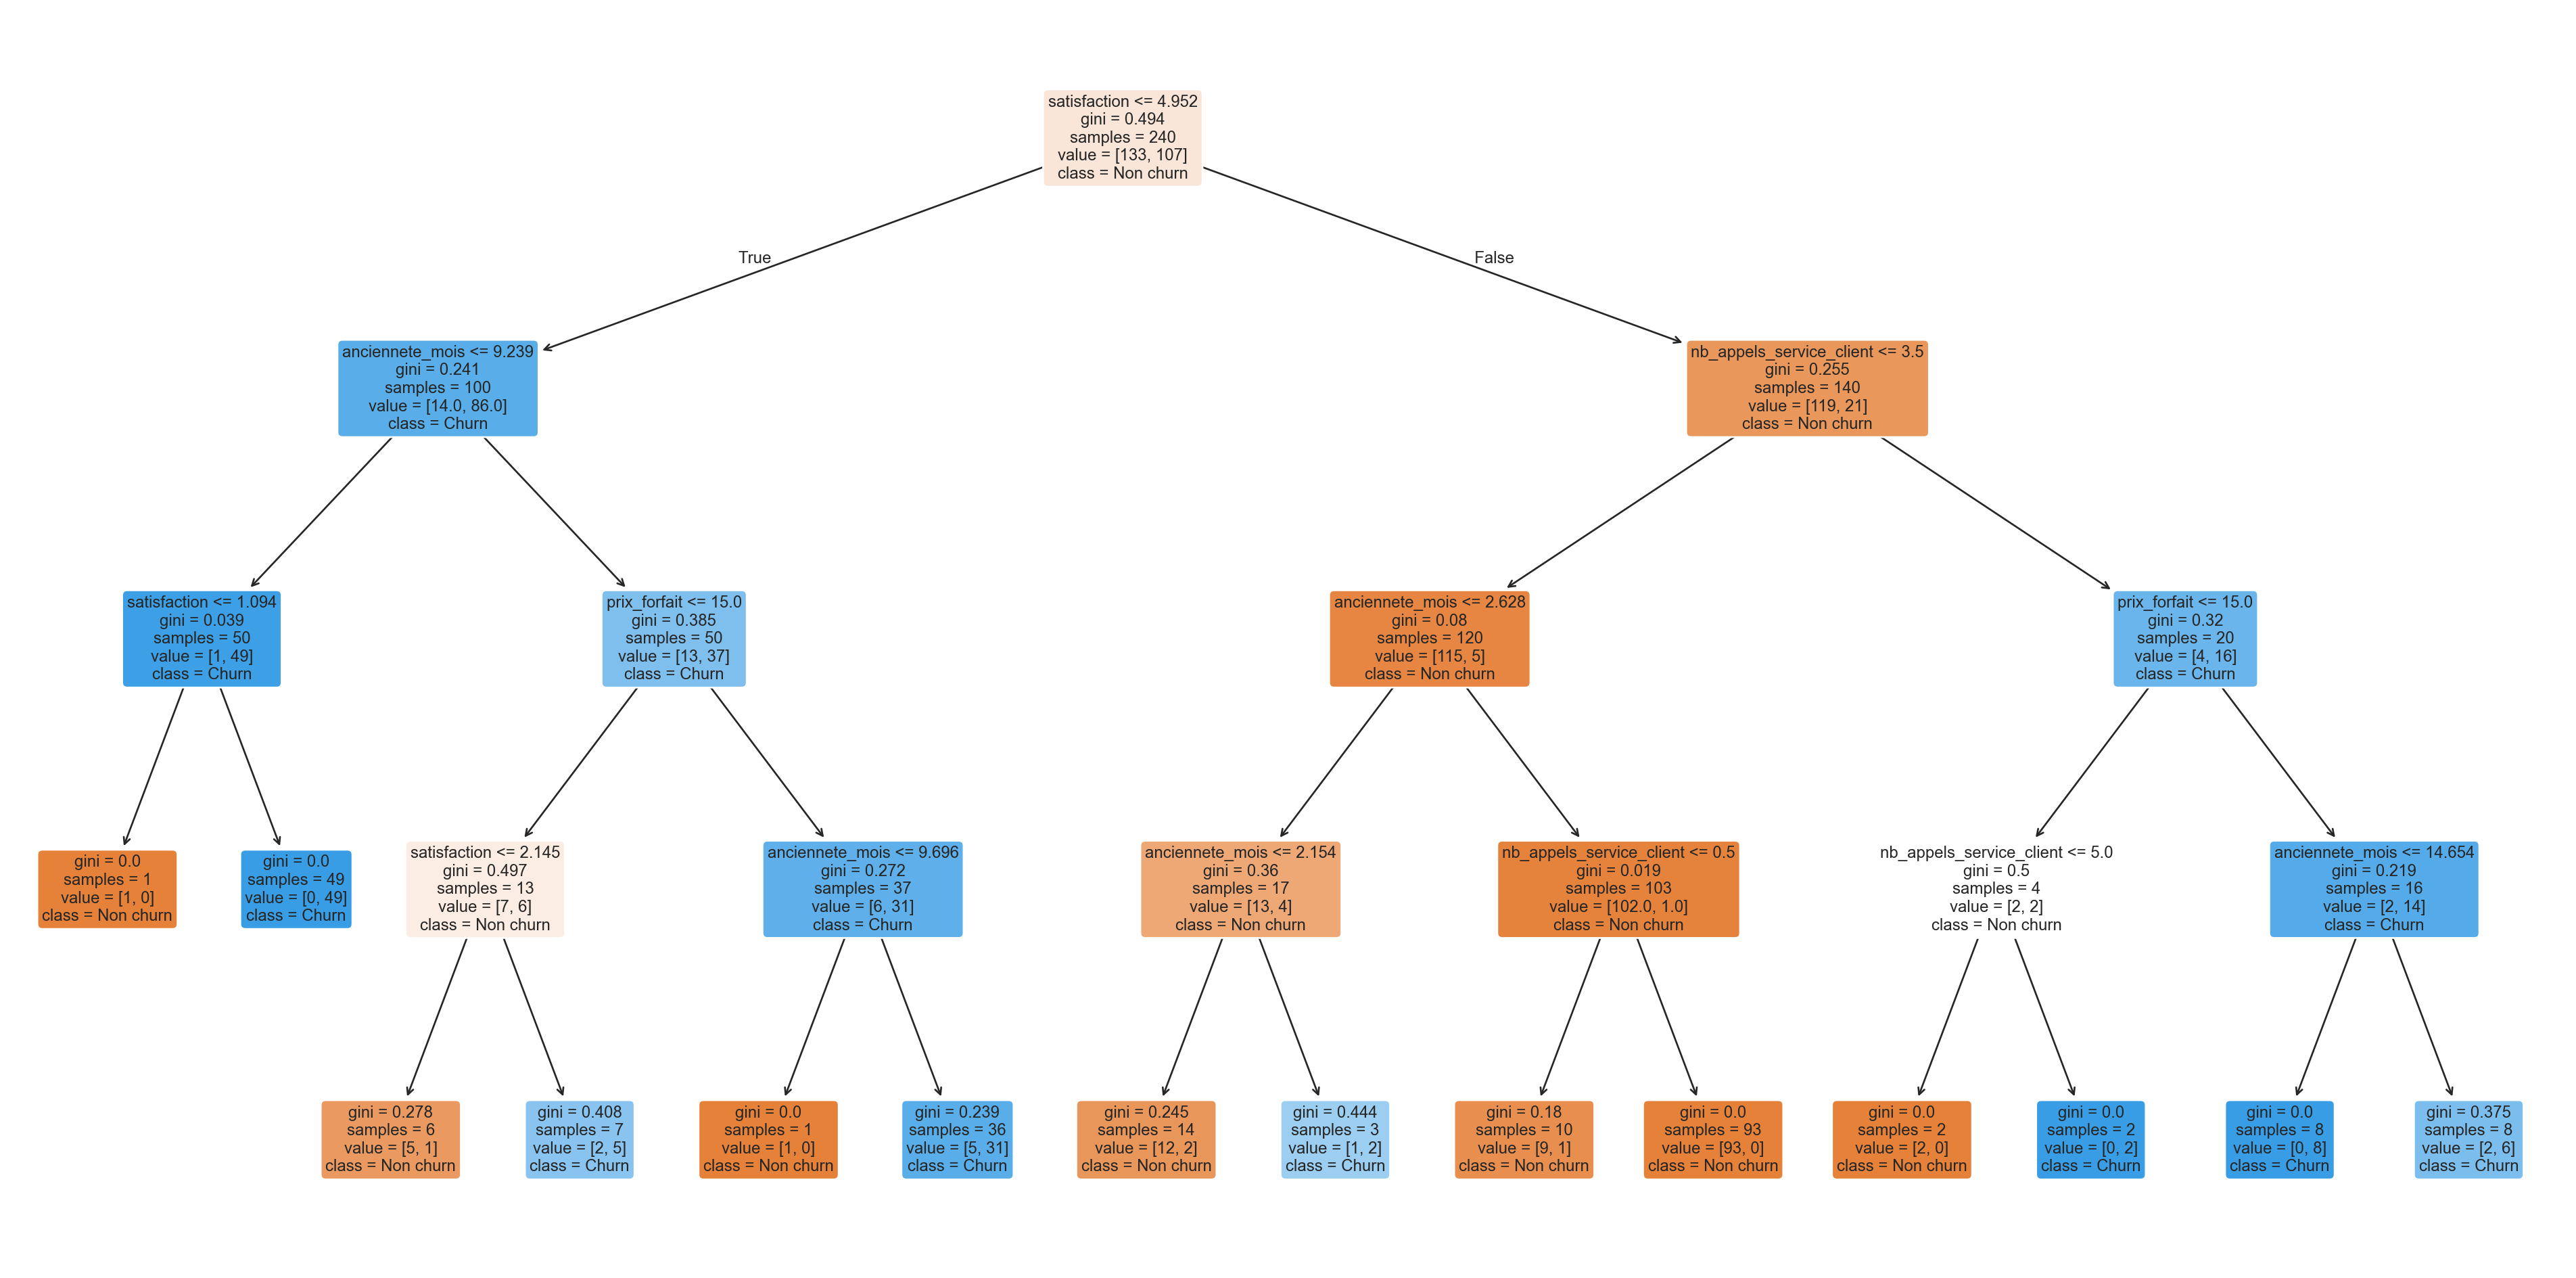

In [9]:
# 4. Visualisation
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(arbre, 
          feature_names=X.columns,
          class_names=["Non churn", "Churn"],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
plt.tight_layout()
plt.show()

In [10]:
# 5. Variable racine
# On regarde l'attribut tree_.feature[0] qui est l'index de la feature racine
feature_racine = X.columns[arbre.tree_.feature[0]]
seuil_racine = arbre.tree_.threshold[0]
print(f"Variable racine : {feature_racine}")
print(f"Seuil : {seuil_racine:.2f}")

Variable racine : satisfaction
Seuil : 4.95


In [11]:
# Exemple de régression : prédire le prix d'un appartement
np.random.seed(42)
n = 200

df_immo = pd.DataFrame({
    "surface": np.random.uniform(30, 150, n),
    "etage": np.random.randint(0, 10, n),
})

# Relation non-linéaire (avec effet de seuil : premium au-dessus de 80m²)
df_immo["prix"] = (
    2000 * df_immo["surface"]
    + 1000 * df_immo["etage"]
    + np.where(df_immo["surface"] > 80, 50_000, 0)  # prime > 80m²
    + np.random.normal(0, 10_000, n)
).round().astype(int)

X = df_immo.drop(columns="prix")
y = df_immo["prix"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Arbre de régression
arbre_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
arbre_reg.fit(X_train, y_train)

# Comparaison avec régression linéaire
lr = LinearRegression().fit(X_train, y_train)

print("Sur le test :")
print(f"  Régression linéaire : R² = {lr.score(X_test, y_test):.3f}")
print(f"  Arbre de régression : R² = {arbre_reg.score(X_test, y_test):.3f}")

Sur le test :
  Régression linéaire : R² = 0.970
  Arbre de régression : R² = 0.983


In [12]:
#| label: fig-overfit-tree
#| fig-cap: Impact de la profondeur sur l'overfitting

# Comparer plusieurs profondeurs
profondeurs = [1, 2, 3, 5, 10, 20, None]  # None = pas de limite
resultats = []

X = clients.drop(columns="churn")
y = clients["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for d in profondeurs:
    arbre = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbre.fit(X_train, y_train)
    resultats.append({
        "max_depth": d if d else "None",
        "acc_train": arbre.score(X_train, y_train),
        "acc_test": arbre.score(X_test, y_test),
        "profondeur_reelle": arbre.get_depth(),
        "nb_feuilles": arbre.get_n_leaves()
    })

res_df = pd.DataFrame(resultats)
print(res_df.round(3).to_string(index=False))

max_depth  acc_train  acc_test  profondeur_reelle  nb_feuilles
        1      0.854     0.800                  1            2
        2      0.904     0.800                  2            4
        3      0.912     0.833                  3            8
        5      0.967     0.833                  5           21
       10      0.996     0.800                 10           34
       20      1.000     0.783                 11           35
     None      1.000     0.783                 11           35


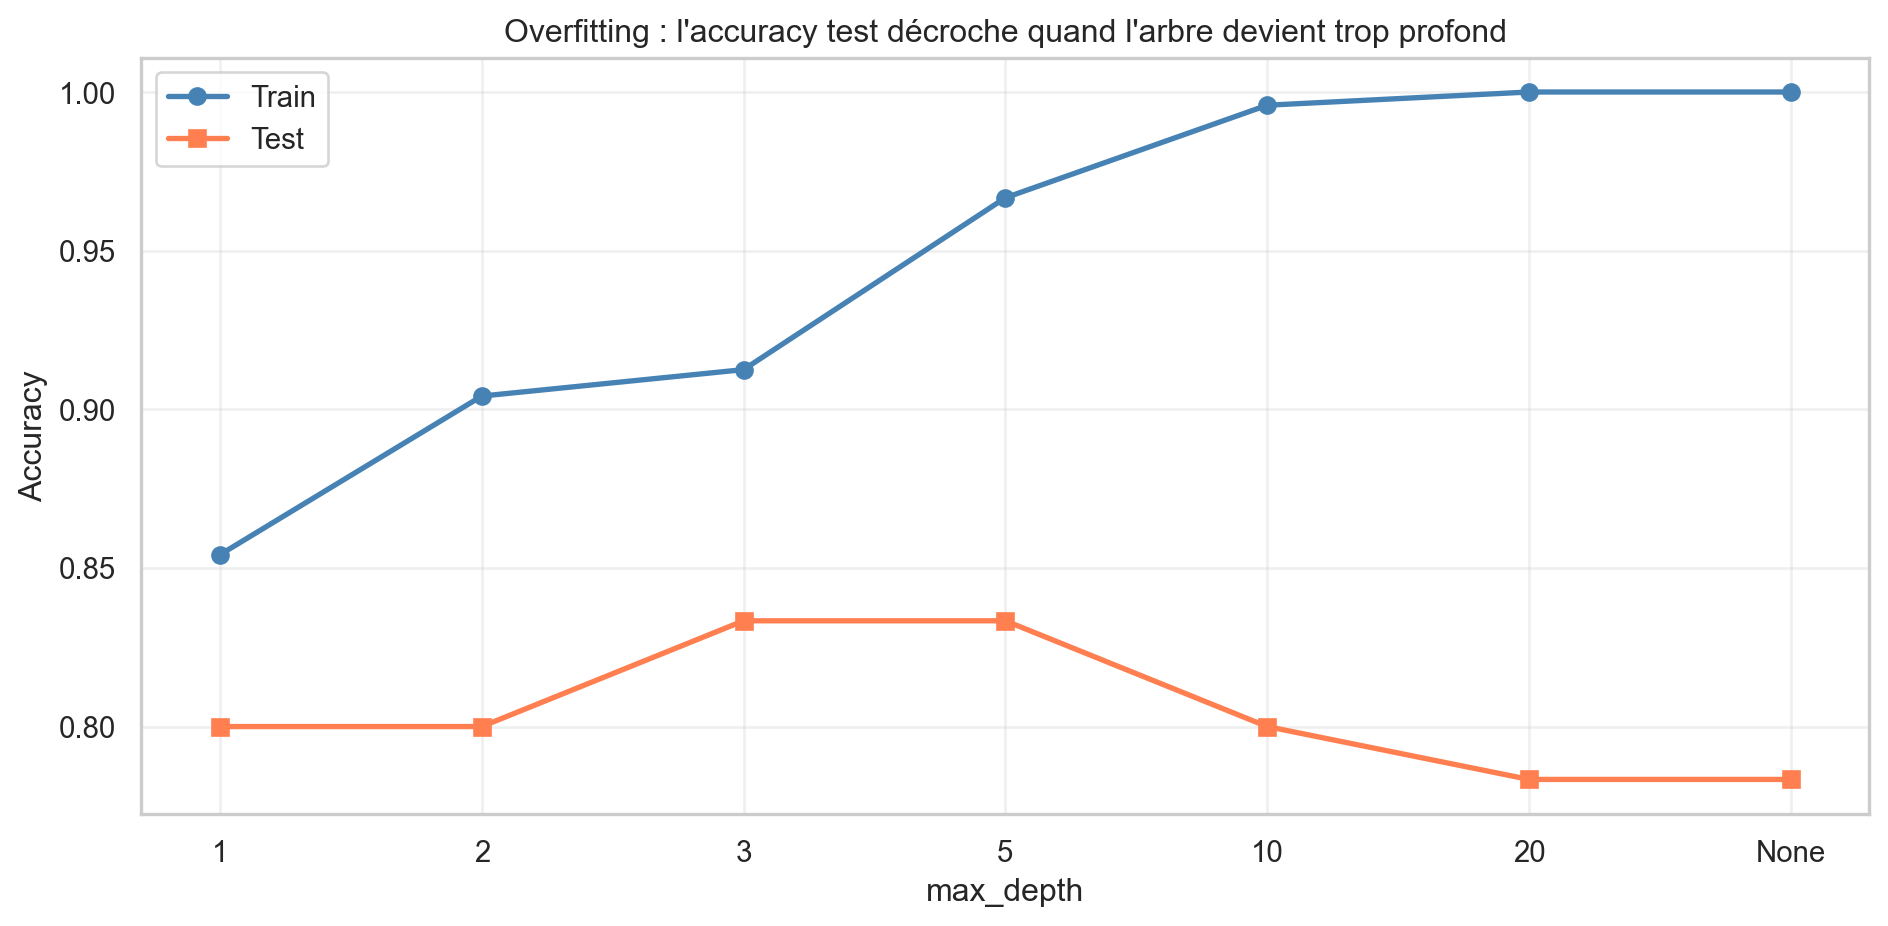

In [13]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(profondeurs))
labels = [str(d) if d else "None" for d in profondeurs]

ax.plot(x_pos, res_df["acc_train"], "o-", linewidth=2, label="Train", color="steelblue")
ax.plot(x_pos, res_df["acc_test"], "s-", linewidth=2, label="Test", color="coral")

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Overfitting : l'accuracy test décroche quand l'arbre devient trop profond")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

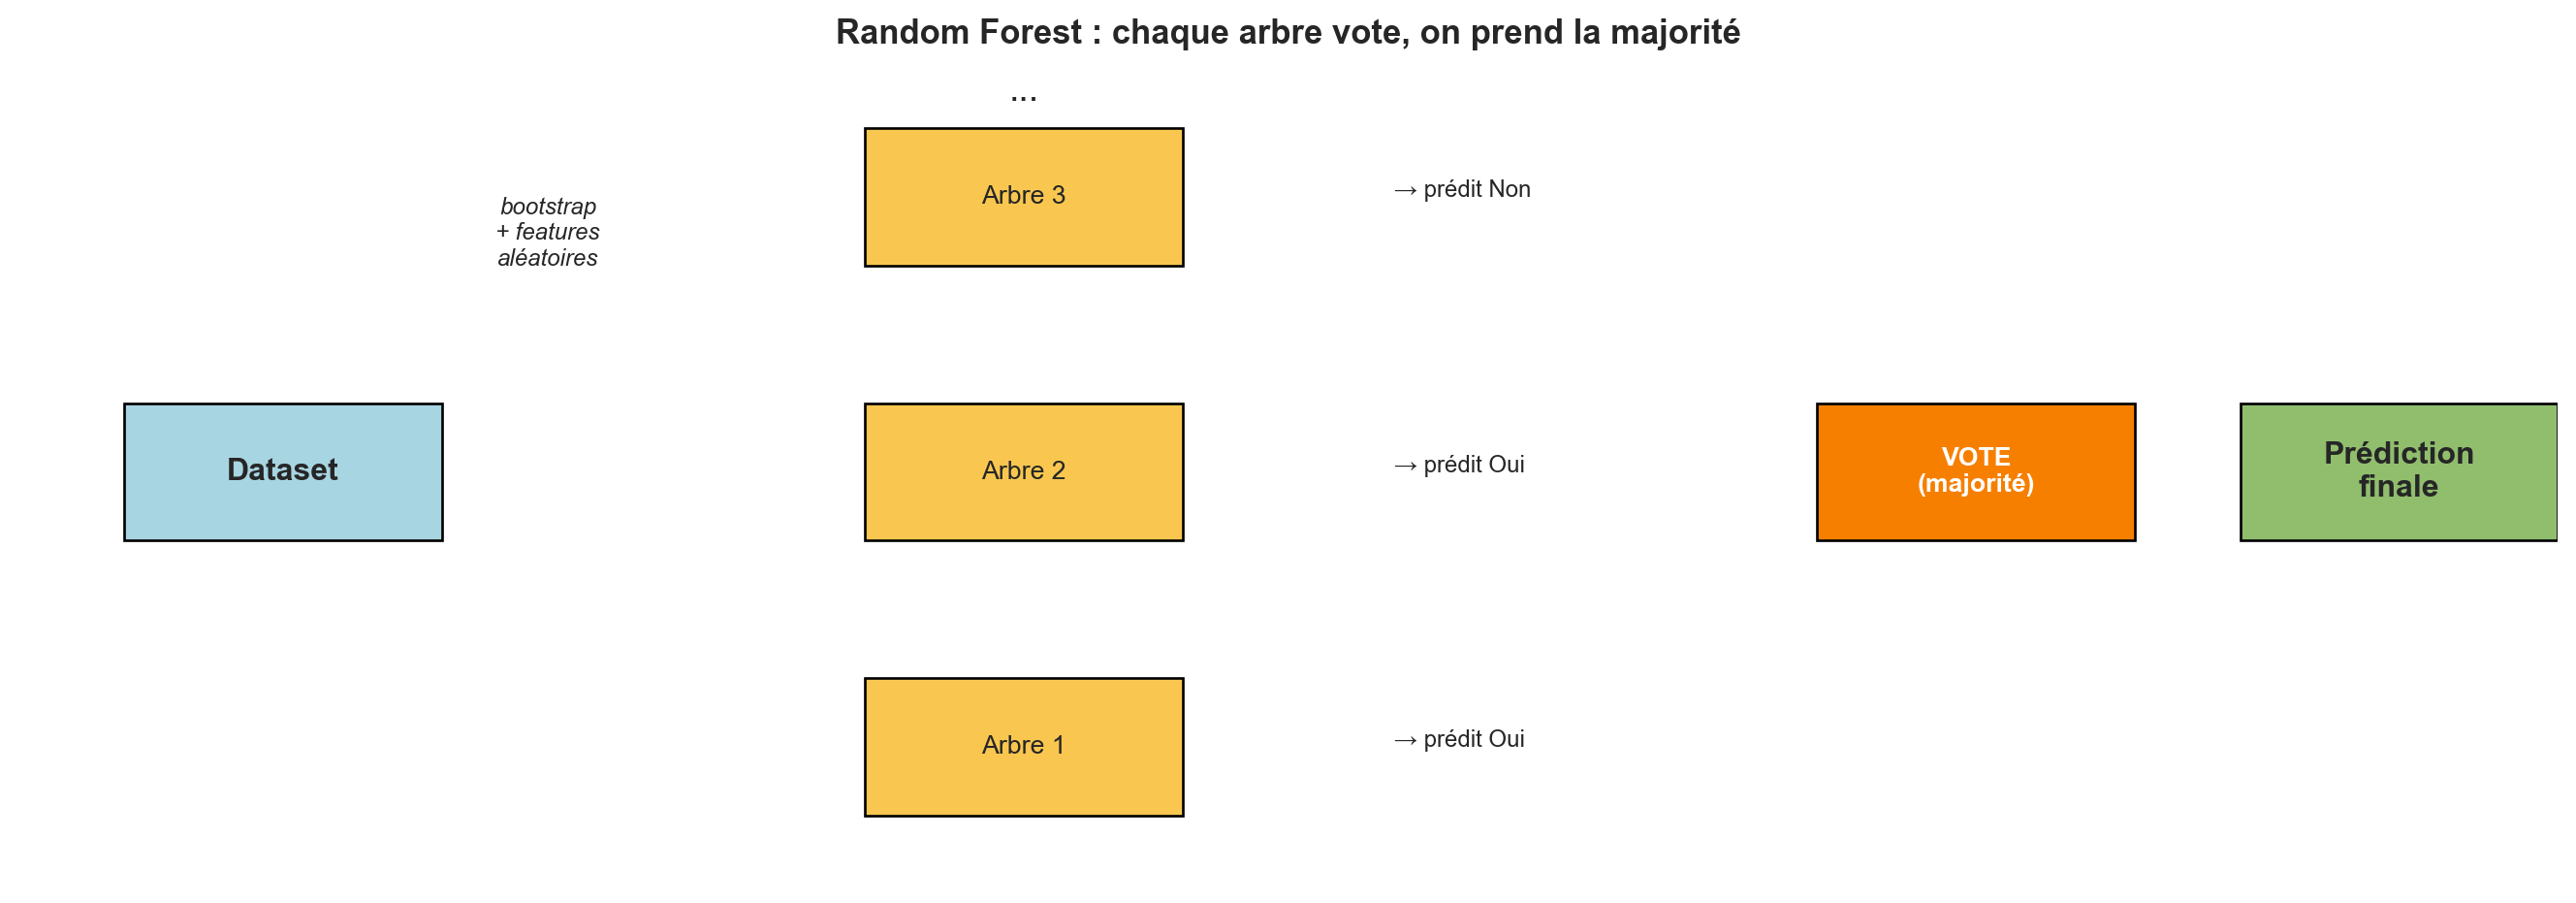

In [14]:
#| label: fig-rf-concept
#| fig-cap: 'Concept du Random Forest : plusieurs arbres qui votent'

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

# Dataset
ax.add_patch(plt.Rectangle((0.5, 2.5), 1.5, 1, facecolor="#a8d5e2", edgecolor="black"))
ax.text(1.25, 3, "Dataset", ha="center", va="center", fontweight="bold")

# N arbres
for i, y_pos in enumerate([0.5, 2.5, 4.5]):
    ax.add_patch(plt.Rectangle((4, y_pos), 1.5, 1, facecolor="#f9c74f", edgecolor="black"))
    ax.text(4.75, y_pos + 0.5, f"Arbre {i+1}", ha="center", va="center", fontsize=10)
    # Flèche dataset → arbre
    ax.annotate("", xy=(4, y_pos + 0.5), xytext=(2, 3), 
                arrowprops=dict(arrowstyle="->", lw=1.5, alpha=0.5))

ax.text(4.75, 5.7, "...", ha="center", fontsize=14)
ax.text(2.5, 4.5, "bootstrap\n+ features\naléatoires", ha="center", fontsize=9, style="italic")

# Prédictions individuelles
for i, y_pos in enumerate([0.5, 2.5, 4.5]):
    ax.text(6.5, y_pos + 0.5, f"→ prédit {['Oui', 'Oui', 'Non'][i]}", fontsize=9)

# Vote / moyenne
ax.add_patch(plt.Rectangle((8.5, 2.5), 1.5, 1, facecolor="#f77f00", edgecolor="black"))
ax.text(9.25, 3, "VOTE\n(majorité)", ha="center", va="center", fontweight="bold", color="white", fontsize=10)

for y_pos in [0.5, 2.5, 4.5]:
    ax.annotate("", xy=(8.5, 3), xytext=(7.3, y_pos + 0.5),
                arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.5))

# Prédiction finale
ax.add_patch(plt.Rectangle((10.5, 2.5), 1.5, 1, facecolor="#90be6d", edgecolor="black"))
ax.text(11.25, 3, "Prédiction\nfinale", ha="center", va="center", fontweight="bold")

ax.annotate("", xy=(10.5, 3), xytext=(10, 3),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.set_title("Random Forest : chaque arbre vote, on prend la majorité", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Random Forest sur le même dataset
rf = RandomForestClassifier(
    n_estimators=100,   # 100 arbres
    max_depth=5,        # chaque arbre limité à profondeur 5
    random_state=42,
    n_jobs=-1           # utilise tous les CPU
)

rf.fit(X_train, y_train)
print(f"Random Forest accuracy train : {rf.score(X_train, y_train):.3f}")
print(f"Random Forest accuracy test  : {rf.score(X_test, y_test):.3f}")

# Comparaison avec un arbre simple
arbre_simple = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
print(f"\nArbre simple accuracy test   : {arbre_simple.score(X_test, y_test):.3f}")
print(f"Random Forest accuracy test    : {rf.score(X_test, y_test):.3f}")

Random Forest accuracy train : 0.954
Random Forest accuracy test  : 0.817

Arbre simple accuracy test   : 0.833
Random Forest accuracy test    : 0.817


In [16]:
# Feature importance
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.to_string(index=False))

                 feature  importance
            satisfaction    0.652095
nb_appels_service_client    0.184204
         anciennete_mois    0.123745
            prix_forfait    0.039956


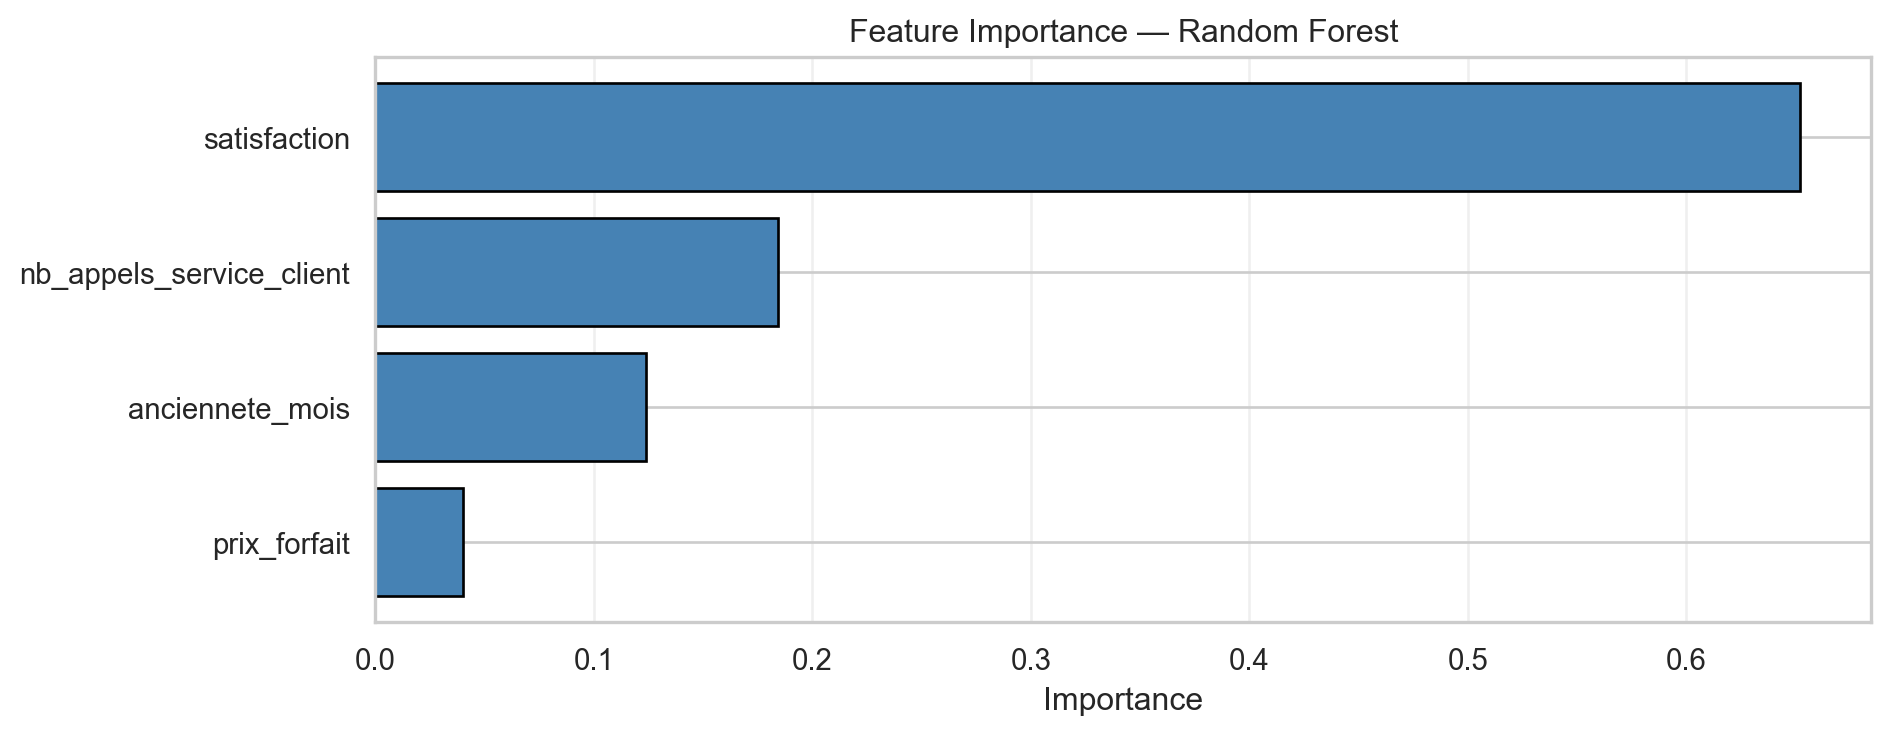

In [17]:
#| label: fig-importance
#| fig-cap: Importance des features dans le Random Forest

fig, ax = plt.subplots(figsize=(10, 4))
importances_sorted = importances.sort_values("importance")
ax.barh(importances_sorted["feature"], importances_sorted["importance"],
        color="steelblue", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Random Forest")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [18]:
#| eval: false
# TODO: Exercice 2

In [19]:
# Split
X = clients.drop(columns="churn")
y = clients["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Les 3 modèles
modeles = {
    "DecisionTree (d=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest (100 arbres)": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=1000),
}

resultats = []
for nom, mod in modeles.items():
    mod.fit(X_train, y_train)
    resultats.append({
        "modèle": nom,
        "acc_train": mod.score(X_train, y_train),
        "acc_test": mod.score(X_test, y_test),
        "gap": mod.score(X_train, y_train) - mod.score(X_test, y_test)
    })

print(pd.DataFrame(resultats).round(3).to_string(index=False))

                   modèle  acc_train  acc_test   gap
       DecisionTree (d=5)      0.967     0.833 0.133
RandomForest (100 arbres)      0.954     0.817 0.138
       LogisticRegression      0.833     0.767 0.067


In [20]:
# 3-4. Feature importance
arbre = modeles["DecisionTree (d=5)"]
rf = modeles["RandomForest (100 arbres)"]

imp_arbre = pd.Series(arbre.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature importance — Decision Tree :")
print(imp_arbre.round(3).to_string())

print("\nFeature importance — Random Forest :")
print(imp_rf.round(3).to_string())

print(f"\nVariable #1 selon l'arbre : {imp_arbre.index[0]}")
print(f"Variable #1 selon le RF   : {imp_rf.index[0]}")

Feature importance — Decision Tree :
satisfaction                0.609
nb_appels_service_client    0.222
anciennete_mois             0.122
prix_forfait                0.047

Feature importance — Random Forest :
satisfaction                0.652
nb_appels_service_client    0.184
anciennete_mois             0.124
prix_forfait                0.040

Variable #1 selon l'arbre : satisfaction
Variable #1 selon le RF   : satisfaction


In [21]:
#| eval: false
# TODO: Exercice bilan

In [22]:
# Création du dataset
np.random.seed(123)
n = 800

credit = pd.DataFrame({
    "age": np.random.uniform(20, 70, n),
    "revenu_mensuel": np.random.gamma(2, 1500, n),
    "duree_emploi_annees": np.random.exponential(5, n).clip(0, 30),
    "ratio_dette": np.random.uniform(0, 1, n),
    "nb_cartes_credit": np.random.poisson(3, n),
})

risque = (
    0.3 * np.exp(-((credit["age"] - 35) / 10)**2)
    + 0.5 * (credit["revenu_mensuel"] < 2000) * (credit["ratio_dette"] > 0.5)
    + 0.2 * (credit["duree_emploi_annees"] < 1)
    + np.random.uniform(0, 0.3, n)
)
credit["defaut"] = (risque > 0.5).astype(int)

print(f"Taux de défaut : {credit['defaut'].mean()*100:.1f}%")

Taux de défaut : 28.4%


In [23]:
# 2. Split
X = credit.drop(columns="defaut")
y = credit["defaut"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3-4. Modèles
modeles = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree (d=5)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "RandomForest (200 arbres)": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5, 
        random_state=42, n_jobs=-1
    ),
}

resultats = []
for nom, mod in modeles.items():
    mod.fit(X_train, y_train)
    resultats.append({
        "modèle": nom,
        "acc_train": mod.score(X_train, y_train),
        "acc_test": mod.score(X_test, y_test),
        "gap": mod.score(X_train, y_train) - mod.score(X_test, y_test)
    })

print(pd.DataFrame(resultats).round(3).to_string(index=False))

                   modèle  acc_train  acc_test   gap
       LogisticRegression      0.816     0.794 0.022
       DecisionTree (d=5)      0.928     0.894 0.034
RandomForest (200 arbres)      0.952     0.919 0.033


In [24]:
# 5. Baseline
baseline = (y_test == 0).mean()
print(f"Baseline (prédire 'pas de défaut') : {baseline:.3f}")

Baseline (prédire 'pas de défaut') : 0.719


In [25]:
# 6. Feature importance
rf = modeles["RandomForest (200 arbres)"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature importance du Random Forest :")
print(imp.round(3).to_string())
print(f"\nTop 3 variables : {imp.head(3).index.tolist()}")

Feature importance du Random Forest :
revenu_mensuel         0.403
ratio_dette            0.305
age                    0.160
duree_emploi_annees    0.116
nb_cartes_credit       0.016

Top 3 variables : ['revenu_mensuel', 'ratio_dette', 'age']


In [26]:
# 7. Conclusion
acc_lr = resultats[0]["acc_test"]
acc_rf = resultats[2]["acc_test"]
gain = (acc_rf - acc_lr) * 100

print(f"Logistic Regression : {acc_lr:.3f}")
print(f"Random Forest       : {acc_rf:.3f}")
print(f"Gain du RF          : {gain:+.1f} points")

if gain > 2:
    print("\n✅ Le Random Forest apporte un vrai gain, on le garde.")
else:
    print("\n⚠️ Gain marginal — on peut garder la logistique pour la simplicité.")

Logistic Regression : 0.794
Random Forest       : 0.919
Gain du RF          : +12.5 points

✅ Le Random Forest apporte un vrai gain, on le garde.
